In [ ]:
#BASELINE MODEL - logistic regression model for predicting management strategy, 81% baseline accuracy.

import pandas as pd
import numpy as np
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import RobustScaler
from sklearn.preprocessing import OneHotEncoder
from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_validate
from sklearn.linear_model import LogisticRegression
import matplotlib.pyplot as plt
import math
import seaborn as sns


In [33]:


data = pd.read_excel("/Users/simonwilliams/code/simonwilliams32/MRI_project/raw_data/synthetic_vestibular_schwannoma_data.xlsx")
data.tail()

,age_at_diagnosis,Sex,BMI,tumour_laterality,Scan 1: Volume,linear_regression_growth_rate_cm3,charlson_comorbidity_index,koos_grade_at_presentation,Management
4995,45,M,26.667706,R,6538.956,0.504685,0,4,Surgery
4996,27,F,21.561009,L,7037.702,0.494394,2,4,Surgery
4997,74,M,NaN,L,7297.534,0.430498,4,3,SRS
4998,67,F,25.622936,L,0.000,NaN,2,1,Surveillance
4999,66,F,26.097113,R,11921.273,1.303475,2,4,Surgery


In [26]:
#DATA CLEANING / PRE-PROCESSING
# Drop duplicates
data.duplicated().sum()
data1 = data.drop_duplicates()

#Missing data
data1.isnull().sum().sort_values(ascending=False)/len(data1)
imputer = SimpleImputer(strategy="mean")

#Mean imputation of tumour growth rate
imputer.fit(data1[['linear_regression_growth_rate_cm3']])
data1['linear_regression_growth_rate_cm3'] = imputer.transform(data1[['linear_regression_growth_rate_cm3']])
data1.isnull().sum().sort_values(ascending=False)/len(data1)

#Median imputation of BMI
imputer_bmi = SimpleImputer(strategy="median")
imputer_bmi.fit(data1[['BMI']])
data1['BMI'] = imputer_bmi.transform(data1[['BMI']])
data1.isnull().sum().sort_values(ascending=False)/len(data1)

#numeric feature scaling
data2 = data1.copy()
cols_to_scale = ['BMI', 'Scan 1: Volume', 'linear_regression_growth_rate_cm3', 'charlson_comorbidity_index', 'age_at_diagnosis']
rb_scaler = RobustScaler()
rb_scaler.fit(data2[cols_to_scale])
data2[cols_to_scale] = rb_scaler.transform(data2[cols_to_scale])

#One Hot Encoding Sex, koos grade, and tumour_laterality

categorical_cols = ["Sex", "koos_grade_at_presentation", "tumour_laterality"]
ohe = OneHotEncoder(sparse_output=False, drop=None, handle_unknown="ignore")
ohe.fit(data2[categorical_cols])
encoded = ohe.transform(data2[categorical_cols])
encoded_df = pd.DataFrame(encoded, columns=ohe.get_feature_names_out(categorical_cols), index=data2.index)
data3 = pd.concat([data2.drop(columns=categorical_cols), encoded_df], axis=1)

#Drop dummy columns
data4 = data3.drop(columns=["Sex_F", "tumour_laterality_L"])
data4


/var/folders/h2/tppndm2j46l7bsmlhqgvm8lw0000gn/T/ipykernel_88029/3035322293.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data1['linear_regression_growth_rate_cm3'] = imputer.transform(data1[['linear_regression_growth_rate_cm3']])
/var/folders/h2/tppndm2j46l7bsmlhqgvm8lw0000gn/T/ipykernel_88029/3035322293.py:18: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data1['BMI'] = imputer_bmi.transform(data1[['BMI']])


,age_at_diagnosis,BMI,Scan 1: Volume,linear_regression_growth_rate_cm3,charlson_comorbidity_index,Management,Sex_M,koos_grade_at_presentation_1,koos_grade_at_presentation_2,koos_grade_at_presentation_3,koos_grade_at_presentation_4,tumour_laterality_R
0,-0.666667,1.183709,-0.366914,-0.748928,-1.0,SRS,1.0,1.0,0.0,0.0,0.0,1.0
1,0.416667,5.883893,-0.178468,-1.040535,0.0,Surveillance,0.0,1.0,0.0,0.0,0.0,0.0
2,-2.583333,-1.982222,-0.323470,-1.195681,-1.0,Surveillance,0.0,1.0,0.0,0.0,0.0,1.0
3,-0.333333,0.000000,-0.416852,0.421350,-1.0,SRS,0.0,1.0,0.0,0.0,0.0,1.0
4,-0.166667,0.870253,-0.416852,0.667744,0.0,SRS,1.0,0.0,0.0,0.0,1.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...
4995,-1.333333,1.131815,2.924266,0.536533,-1.0,Surgery,1.0,0.0,0.0,0.0,1.0,1.0
4996,-2.833333,-12.994138,3.179103,0.513660,0.0,Surgery,0.0,0.0,0.0,0.0,1.0,0.0
4997,1.083333,0.000000,3.311866,0.371644,1.0,SRS,1.0,0.0,0.0,1.0,0.0,0.0
4998,0.500000,-1.758190,-0.416852,0.421350,0.0,Surveillance,0.0,1.0,0.0,0.0,0.0,0.0


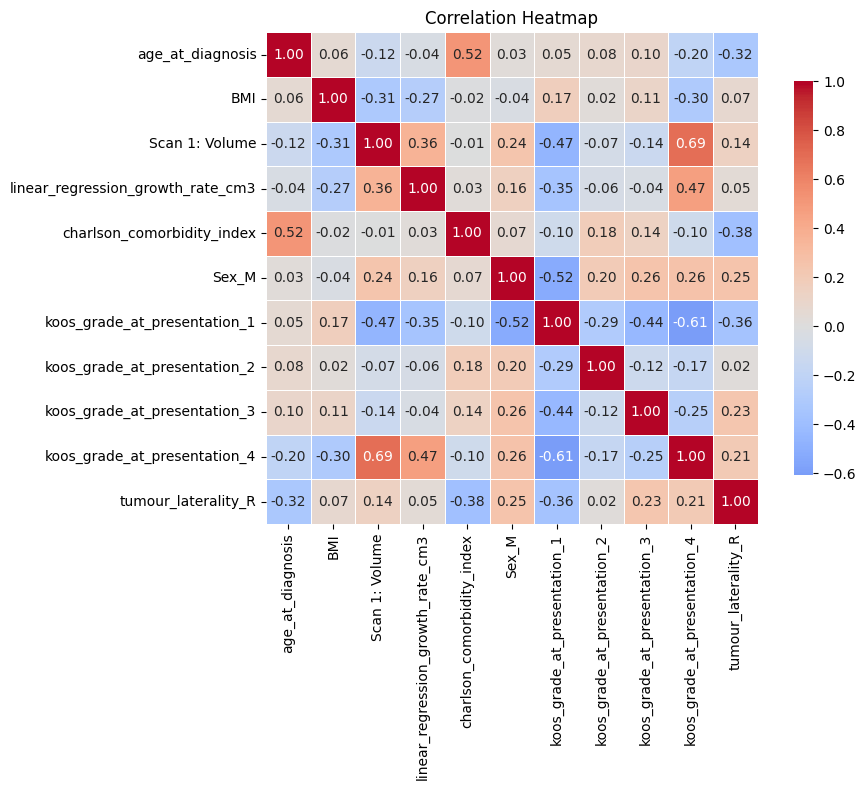

In [32]:
# Compute correlation matrix
corr = data4.corr(numeric_only=True)

# Plot
plt.figure(figsize=(10, 8))

sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    square=True,
    linewidths=0.5,
    cbar_kws={"shrink": 0.8}
)

plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()

In [38]:
#Running Multiclass Logistic Regression
X = data4.drop(columns=["Management"])
y = data4["Management"]
model = LogisticRegression(max_iter=2000)
cv_results = cross_validate(model, X, y, cv=5)

print("Fold accuracies:", cv_results["test_score"])
print("Mean accuracy:", np.mean(cv_results["test_score"]))
print("Std:", np.std(cv_results["test_score"]))

Fold accuracies: [0.8246493  0.81663327 0.79839519 0.80140421 0.8004012 ]
Mean accuracy: 0.8082966333871353
Std: 0.010438304996103197
